In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model  import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [4]:
data=pd.read_csv('bhp_ML.csv')
data

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689.834926
13196,Richards Town,4 BHK,3600.0,5.0,400.00,4,11111.111111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258.545136
13198,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407.336319


In [5]:
data.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [6]:
data.tail()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
13195,Whitefield,5 Bedroom,3453.0,4.0,231.0,5,6689.834926
13196,Richards Town,4 BHK,3600.0,5.0,400.0,4,11111.111111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.0,2,5258.545136
13198,Padmanabhanagar,4 BHK,4689.0,4.0,488.0,4,10407.336319
13199,Doddathoguru,1 BHK,550.0,1.0,17.0,1,3090.909091


In [7]:
data.isna().sum()

location          0
size              0
total_sqft        0
bath              0
price             0
bhk               0
price_per_sqft    0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(881)

In [9]:
data=data.drop_duplicates()
data

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13194,Green Glen Layout,3 BHK,1715.0,3.0,112.00,3,6530.612245
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689.834926
13196,Richards Town,4 BHK,3600.0,5.0,400.00,4,11111.111111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258.545136


In [10]:
data.dtypes

location              str
size                  str
total_sqft        float64
bath              float64
price             float64
bhk                 int64
price_per_sqft    float64
dtype: object

In [11]:
data.shape

(12319, 7)

In [12]:
data.size

86233

In [13]:
data.columns

Index(['location', 'size', 'total_sqft', 'bath', 'price', 'bhk',
       'price_per_sqft'],
      dtype='str')

In [14]:
data.price.value_counts()

price
65.00     289
75.00     285
60.00     258
55.00     258
45.00     224
         ... 
96.80       1
63.93       1
40.14       1
231.00      1
488.00      1
Name: count, Length: 1952, dtype: int64

In [15]:
data.info()

<class 'pandas.DataFrame'>
Index: 12319 entries, 0 to 13198
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        12319 non-null  str    
 1   size            12319 non-null  str    
 2   total_sqft      12319 non-null  float64
 3   bath            12319 non-null  float64
 4   price           12319 non-null  float64
 5   bhk             12319 non-null  int64  
 6   price_per_sqft  12319 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 769.9 KB


In [16]:
data.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12319.000000,12319.000000,12319.000000,12319.000000,1.231900e+04
mean,1571.758982,2.718240,115.118523,2.824823,8.115050e+03
std,1272.958158,1.367371,153.322899,1.321693,1.104734e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.307692e+03
50%,1282.000000,2.000000,73.310000,3.000000,5.500000e+03
75%,1693.000000,3.000000,123.000000,3.000000,7.452904e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [17]:
correlation=data.select_dtypes(include='number').corr()
correlation

,total_sqft,bath,price,bhk,price_per_sqft
total_sqft,1.000000,0.385959,0.571096,0.339767,-0.008840
bath,0.385959,1.000000,0.449925,0.899168,0.030343
price,0.571096,0.449925,1.000000,0.391145,0.027651
bhk,0.339767,0.899168,0.391145,1.000000,0.030463
price_per_sqft,-0.008840,0.030343,0.027651,0.030463,1.000000


<Axes: >

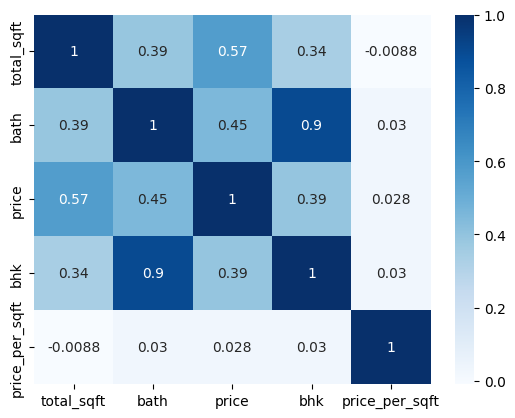

In [18]:
sns.heatmap(correlation,annot=True,cmap='Blues')

<Axes: >

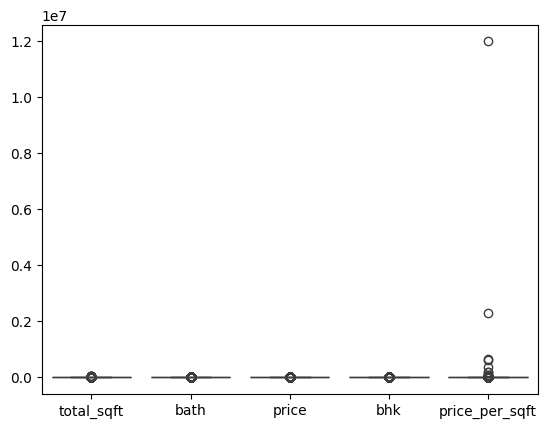

In [19]:
sns.boxplot(data)

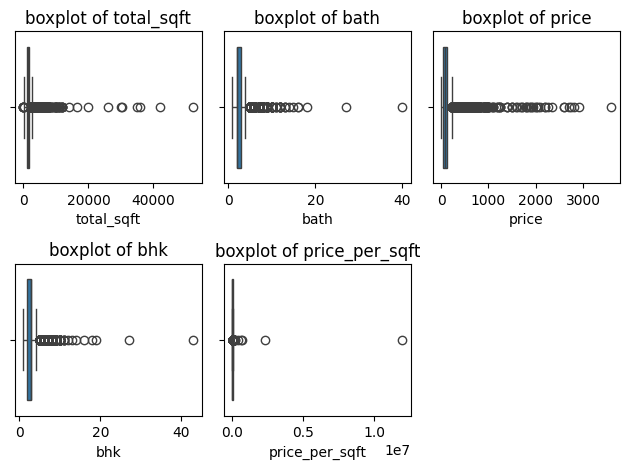

In [20]:
numeric_columns=['total_sqft','bath','price','bhk','price_per_sqft']
for i,column in enumerate(numeric_columns,1):
     plt.subplot(2,3,i)
     sns.boxplot(data=data,x=column)
     plt.title(f'boxplot of {column}')

plt.tight_layout() #everything will be neatly arranged

plt.show()


In [21]:
#dectet outlaiers from IQR 

for  column in numeric_columns:
    Q1=data[column].quantile(0.25)
    Q3=data[column].quantile(0.75)

        
    IQR=Q3-Q1

    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    outliers=data[(data[column]< lower_bound)|(data[column]> upper_bound)]#outliers
    print(f"outliers detected in '{column}'columns:\n",outliers,'\n')

# data = data[(data[column] >= Lower_bound) & (data[column] <= upper_bound)]
# Capping outliers to the bounds
# Use the CLIP method to cap the outliers to the upper and Lower bounds

    data[column]=data[column].clip(lower=lower_bound,upper=upper_bound)

print("data after removing ouliers:\n",data)


outliers detected in 'total_sqft'columns:
                     location       size  total_sqft  bath  price  bhk  \
1           Chikka Tirupathi  4 Bedroom      2600.0   5.0  120.0    4   
6           Old Airport Road      4 BHK      2732.0   4.0  204.0    4   
7               Rajaji Nagar      4 BHK      3300.0   4.0  600.0    4   
11                Whitefield  4 Bedroom      2785.0   5.0  295.0    4   
18     Ramakrishnappa Layout      3 BHK      2770.0   4.0  290.0    3   
...                      ...        ...         ...   ...    ...  ...   
13148              EPIP Zone      4 BHK      3360.0   5.0  221.0    4   
13170         Sarjapur  Road      4 BHK      4050.0   2.0  450.0    4   
13195             Whitefield  5 Bedroom      3453.0   4.0  231.0    5   
13196          Richards Town      4 BHK      3600.0   5.0  400.0    4   
13198        Padmanabhanagar      4 BHK      4689.0   4.0  488.0    4   

       price_per_sqft  
1         4615.384615  
6         7467.057101  
7       

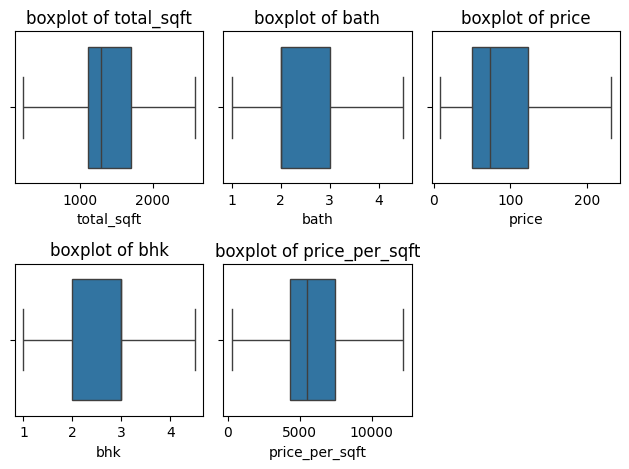

In [22]:
numeric_columns=['total_sqft','bath','price','bhk','price_per_sqft']
for i,column in enumerate(numeric_columns,1):
     plt.subplot(2,3,i)
     sns.boxplot(data=data,x=column)
     plt.title(f'boxplot of {column}')

plt.tight_layout() #everything will be neatly arranged

plt.show()


In [23]:
lb=LabelEncoder()
data['location']=lb.fit_transform(data['location'])
data['size']=lb.fit_transform(data['size'])

In [24]:
x=data.drop('price',axis=1)
x

,location,size,total_sqft,bath,bhk,price_per_sqft
0,416,13,1056.0,2.0,2.0,3699.810606
1,314,19,2582.5,4.5,4.0,4615.384615
2,1173,16,1440.0,2.0,3.0,4305.555556
3,753,16,1521.0,3.0,3.0,6245.890861
4,712,13,1200.0,2.0,2.0,4250.000000
...,...,...,...,...,...,...
13194,471,16,1715.0,3.0,3.0,6530.612245
13195,1246,22,2582.5,4.0,4.5,6689.834926
13196,998,18,2582.5,4.5,4.0,11111.111111
13197,966,13,1141.0,2.0,2.0,5258.545136


In [25]:
y=data['price']
y

0         39.07
1        120.00
2         62.00
3         95.00
4         51.00
          ...  
13194    112.00
13195    231.00
13196    232.50
13197     60.00
13198    232.50
Name: price, Length: 12319, dtype: float64

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [27]:
model=LinearRegression()
model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-0. ,-0.68, 0.07, 3.16, 1.29, 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['location','size','total_sqft','bath','bhk','price_per_sqft']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-87.45
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


In [28]:
y_pred=model.predict(x_test)
y_pred

array([ 79.929266  , 184.89246326,  35.42634692, ...,  59.29291742,
        67.68944063, 112.64771581], shape=(3080,))

In [29]:
model.score(x_test,y_test)

0.9301315392922036

In [30]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)


261.9187657249712

In [31]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_pred)

9.983591545413729

In [32]:
import numpy as np
print(np.sqrt(mean_squared_error(y_test,y_pred)))

16.183904526565
